# Import Libraries

In [1]:
import math
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score

# Load the Dataset

In [2]:
data = pd.read_csv("IBM_HR_analyticisEmployee.csv")

In [3]:
df = data.copy()

In [4]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


| Column                       | Description                                                                 |
| ---------------------------- | --------------------------------------------------------------------------- |
| **Age**                      | Age of the employee.                                                        |
| **Attrition**                | Whether the employee left the company (Yes/No).                             |
| **BusinessTravel**           | Frequency of business travel.                                               |
| **DailyRate**                | Employee's daily pay rate.                                                  |
| **Department**               | Department where the employee works.                                        |
| **DistanceFromHome**         | Distance between the employee's home and workplace.                         |
| **Education**                | Employee's education level (1–5).                                           |
| **EducationField**           | Field of study of the employee.                                             |
| **EmployeeCount**            | Total employee count (constant value = 1).                                  |
| **EmployeeNumber**           | Unique identifier assigned to each employee.                                |
| **EnvironmentSatisfaction**  | Employee's satisfaction with the work environment (1–4).                    |
| **Gender**                   | Employee's gender.                                                          |
| **HourlyRate**               | Employee's hourly pay rate.                                                 |
| **JobInvolvement**           | Level of involvement in the job (1–4).                                      |
| **JobLevel**                 | Employee's job level within the company.                                    |
| **JobRole**                  | Employee's job position or role.                                            |
| **JobSatisfaction**          | Employee's job satisfaction level (1–4).                                    |
| **MaritalStatus**            | Employee's marital status.                                                  |
| **MonthlyIncome**            | Employee's monthly salary.                                                  |
| **MonthlyRate**              | Monthly rate assigned to the employee.                                      |
| **NumCompaniesWorked**       | Number of companies the employee has worked for previously.                 |
| **Over18**                   | Indicates whether the employee is over 18 years old (constant value = "Y"). |
| **OverTime**                 | Whether the employee works overtime (Yes/No).                               |
| **PercentSalaryHike**        | Percentage increase in salary from the previous year.                       |
| **PerformanceRating**        | Employee's performance rating.                                              |
| **RelationshipSatisfaction** | Satisfaction with workplace relationships (1–4).                            |
| **StandardHours**            | Standard working hours (constant value = 80).                               |
| **StockOptionLevel**         | Employee's stock option level.                                              |
| **TotalWorkingYears**        | Total years of professional work experience.                                |
| **TrainingTimesLastYear**    | Number of training sessions attended in the previous year.                  |
| **WorkLifeBalance**          | Employee's work-life balance rating (1–4).                                  |
| **YearsAtCompany**           | Number of years the employee has worked at the company.                     |
| **YearsInCurrentRole**       | Number of years in the current job role.                                    |
| **YearsSinceLastPromotion**  | Years since the employee's last promotion.                                  |
| **YearsWithCurrManager**     | Number of years working with the current manager.                           |


In [5]:
df.shape

(1470, 35)

# EDA

In [6]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [8]:
((df.isnull().sum() / len(df)) * 100)[df.isnull().sum()>0]

Series([], dtype: float64)

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
def drop_constant(df: pd.DataFrame) -> pd.DataFrame:
    df_clean = df.copy()
    constant_cols = []
    
    for col in df_clean.columns:
        unique_count = df_clean[col].nunique()
        
        if unique_count == 1:
            constant_cols.append(col)
            
    if constant_cols:
        print(f"drop:\n{constant_cols}")
        df_clean = df_clean.drop(columns=constant_cols)
        
    return df_clean

In [11]:
df = drop_constant(df)

drop:
['EmployeeCount', 'Over18', 'StandardHours']


In [12]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeNumber',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='str')

In [13]:
df = df.drop(['Attrition', 'EmployeeNumber'], axis=1)

Five columns were removed during data cleaning. Three columns (EmployeeCount, Over18, and StandardHours) contained constant values for all records. EmployeeNumber was removed because it is only a unique identifier, and Attrition was removed because clustering is an unsupervised learning method and does not use a target variable.

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.0,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.0,3.0,4.00,5.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.0,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.0,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.0,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.0,2.0,3.00,5.0
JobSatisfaction,1470.0,2.728571,1.102846,1.0,2.0,3.0,4.00,4.0
MonthlyIncome,1470.0,6502.931293,4707.956783,1009.0,2911.0,4919.0,8379.00,19999.0


In [15]:
df.describe(include="object").T

C:\Users\computer\AppData\Local\Temp\ipykernel_17540\1274302342.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
BusinessTravel,1470,3,Travel_Rarely,1043
Department,1470,3,Research & Development,961
EducationField,1470,6,Life Sciences,606
Gender,1470,2,Male,882
JobRole,1470,9,Sales Executive,326
MaritalStatus,1470,3,Married,673
OverTime,1470,2,No,1054


In [16]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

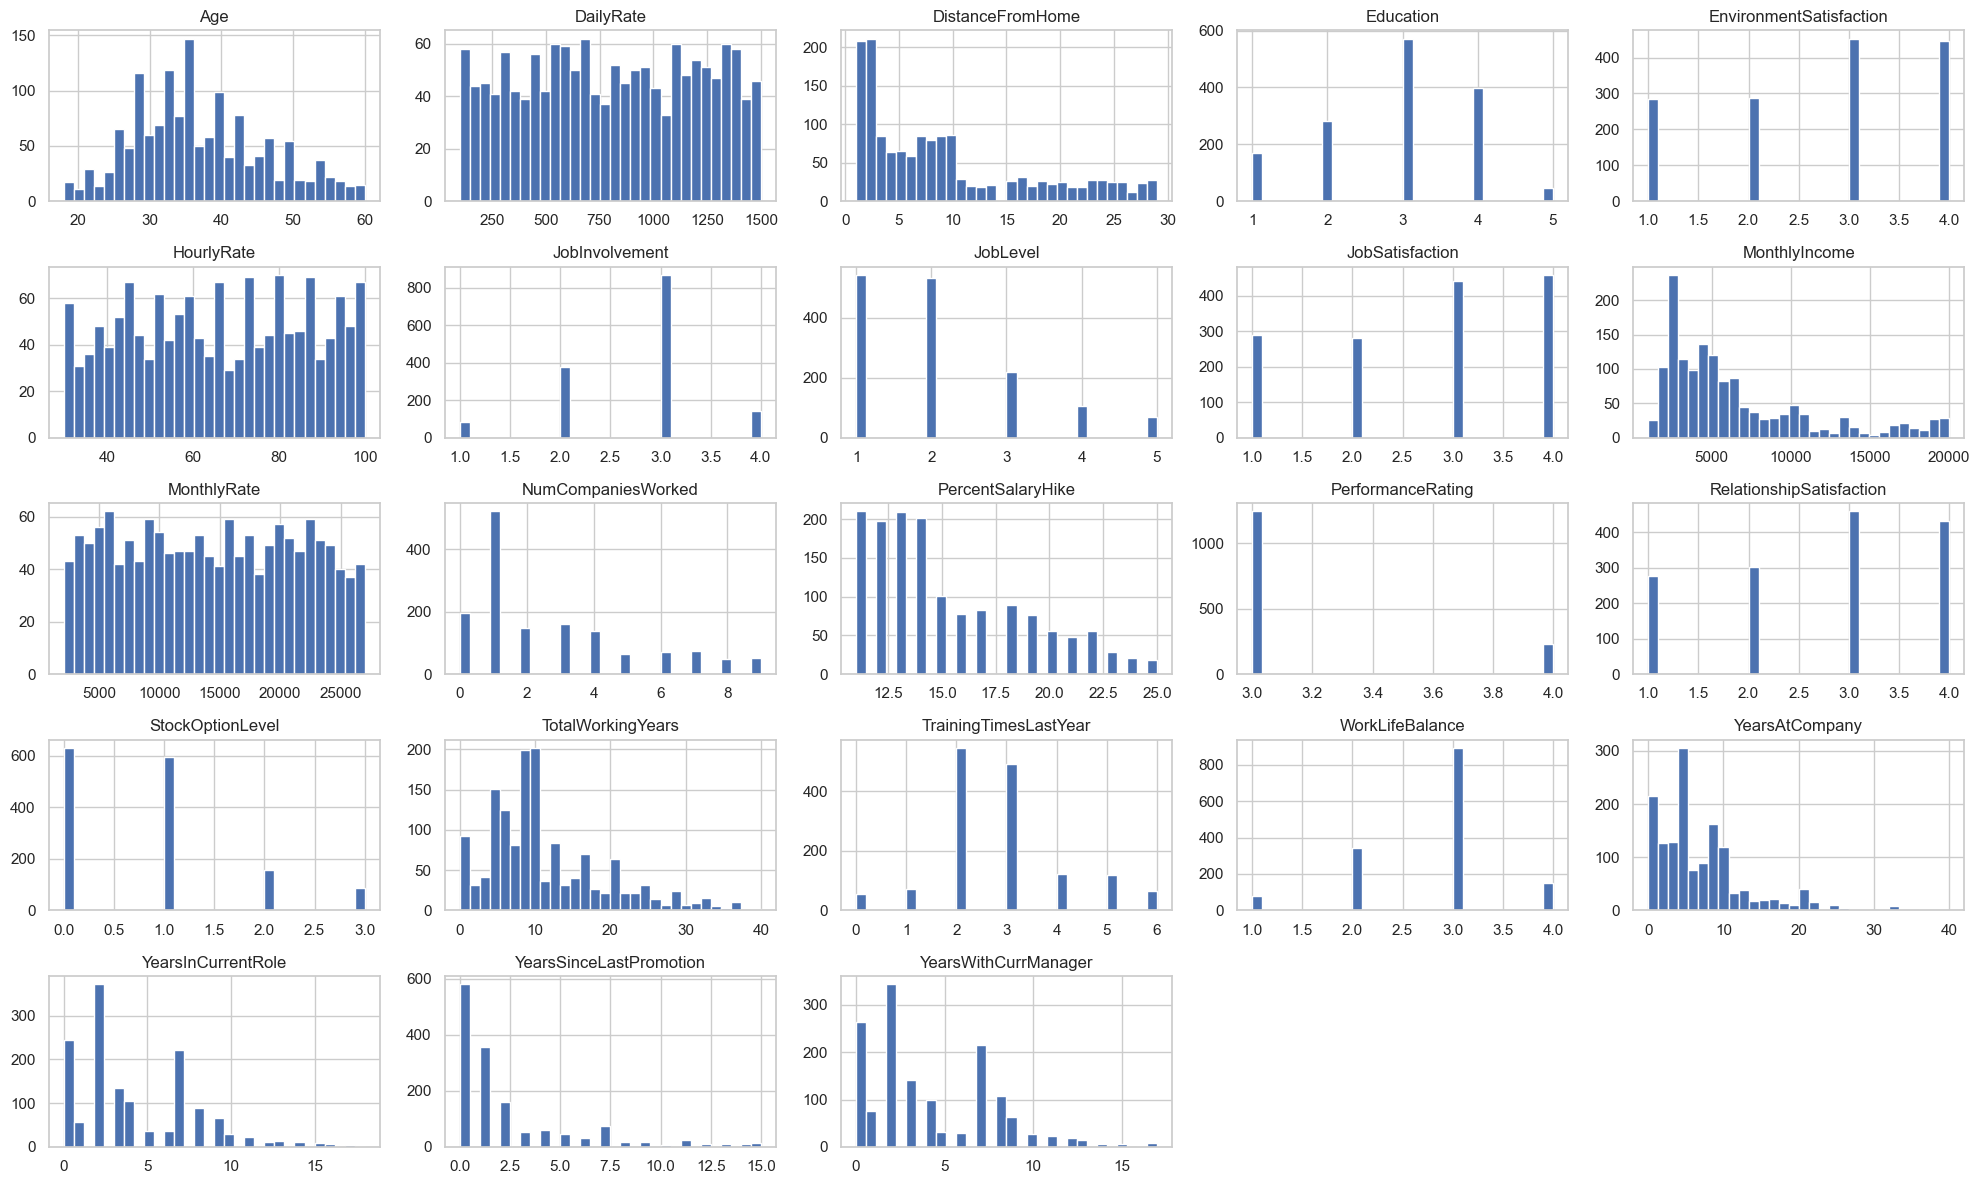

In [17]:
numeric_df.hist(
    figsize=(20, 12),
    bins=30
)

plt.tight_layout()
plt.show()

The histograms indicate that the numerical features have different distribution patterns. Age is approximately normally distributed, while MonthlyIncome, TotalWorkingYears, and YearsAtCompany show positively skewed distributions, with most observations concentrated at lower values and fewer observations at higher values. In addition, variables such as Education, JobLevel, and WorkLifeBalance have discrete distributions because they represent ordinal categories encoded as numerical values rather than continuous measurements.

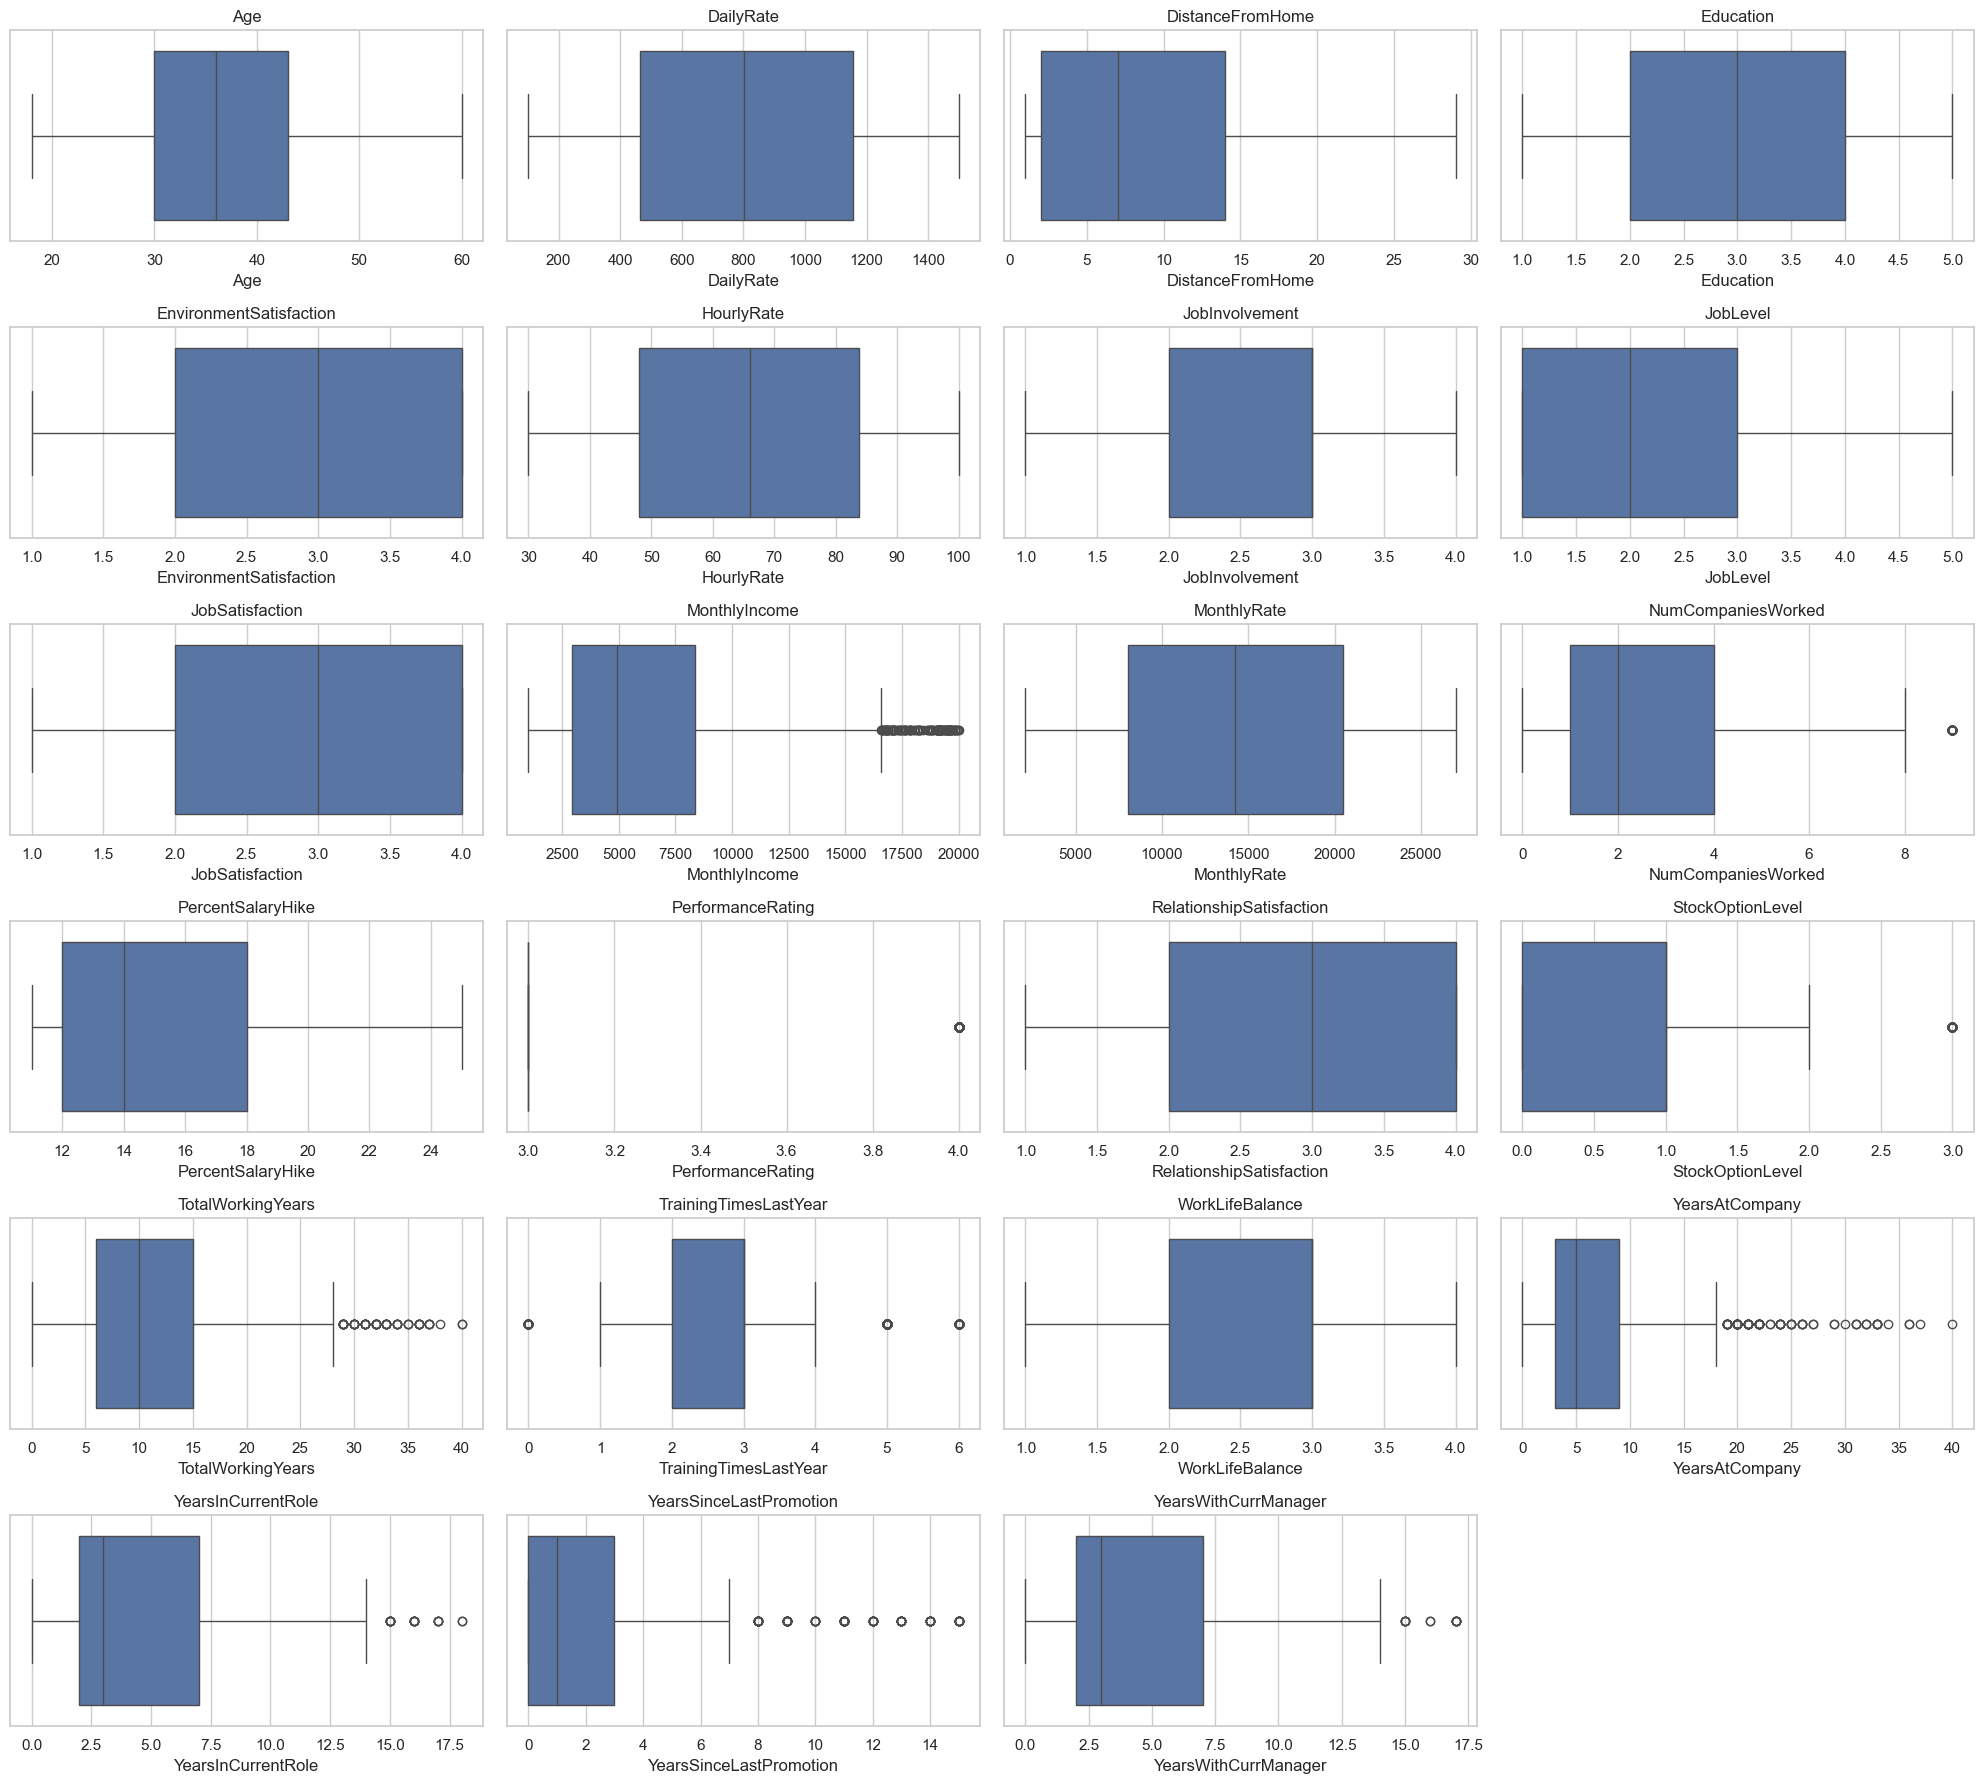

In [18]:
num_cols = numeric_df.columns

n_cols = 4
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 3 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)

for ax in axes[len(num_cols):]:
    ax.remove()

plt.tight_layout()
plt.show()

The boxplots indicate that several numerical features contain outliers, particularly TotalWorkingYears, YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, and YearsWithCurrManager. These values are likely to represent employees with long work experience rather than data entry errors. Therefore, the outliers were retained because they provide meaningful information for clustering analysis.

In [19]:
corr = numeric_df.corr()

corr

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,0.010661,-0.001686,0.208034,0.010146,0.024287,0.029820,0.509604,-0.004892,0.497855,0.028051,0.299635,0.003634,0.001904,0.053535,0.037510,0.680381,-0.019621,-0.021490,0.311309,0.212901,0.216513,0.202089
DailyRate,0.010661,1.000000,-0.004985,-0.016806,0.018355,0.023381,0.046135,0.002966,0.030571,0.007707,-0.032182,0.038153,0.022704,0.000473,0.007846,0.042143,0.014515,0.002453,-0.037848,-0.034055,0.009932,-0.033229,-0.026363
DistanceFromHome,-0.001686,-0.004985,1.000000,0.021042,-0.016075,0.031131,0.008783,0.005303,-0.003669,-0.017014,0.027473,-0.029251,0.040235,0.027110,0.006557,0.044872,0.004628,-0.036942,-0.026556,0.009508,0.018845,0.010029,0.014406
Education,0.208034,-0.016806,0.021042,1.000000,-0.027128,0.016775,0.042438,0.101589,-0.011296,0.094961,-0.026084,0.126317,-0.011111,-0.024539,-0.009118,0.018422,0.148280,-0.025100,0.009819,0.069114,0.060236,0.054254,0.069065
EnvironmentSatisfaction,0.010146,0.018355,-0.016075,-0.027128,1.000000,-0.049857,-0.008278,0.001212,-0.006784,-0.006259,0.037600,0.012594,-0.031701,-0.029548,0.007665,0.003432,-0.002693,-0.019359,0.027627,0.001458,0.018007,0.016194,-0.004999
HourlyRate,0.024287,0.023381,0.031131,0.016775,-0.049857,1.000000,0.042861,-0.027853,-0.071335,-0.015794,-0.015297,0.022157,-0.009062,-0.002172,0.001330,0.050263,-0.002334,-0.008548,-0.004607,-0.019582,-0.024106,-0.026716,-0.020123
JobInvolvement,0.029820,0.046135,0.008783,0.042438,-0.008278,0.042861,1.000000,-0.012630,-0.021476,-0.015271,-0.016322,0.015012,-0.017205,-0.029071,0.034297,0.021523,-0.005533,-0.015338,-0.014617,-0.021355,0.008717,-0.024184,0.025976
JobLevel,0.509604,0.002966,0.005303,0.101589,0.001212,-0.027853,-0.012630,1.000000,-0.001944,0.950300,0.039563,0.142501,-0.034730,-0.021222,0.021642,0.013984,0.782208,-0.018191,0.037818,0.534739,0.389447,0.353885,0.375281
JobSatisfaction,-0.004892,0.030571,-0.003669,-0.011296,-0.006784,-0.071335,-0.021476,-0.001944,1.000000,-0.007157,0.000644,-0.055699,0.020002,0.002297,-0.012454,0.010690,-0.020185,-0.005779,-0.019459,-0.003803,-0.002305,-0.018214,-0.027656
MonthlyIncome,0.497855,0.007707,-0.017014,0.094961,-0.006259,-0.015794,-0.015271,0.950300,-0.007157,1.000000,0.034814,0.149515,-0.027269,-0.017120,0.025873,0.005408,0.772893,-0.021736,0.030683,0.514285,0.363818,0.344978,0.344079


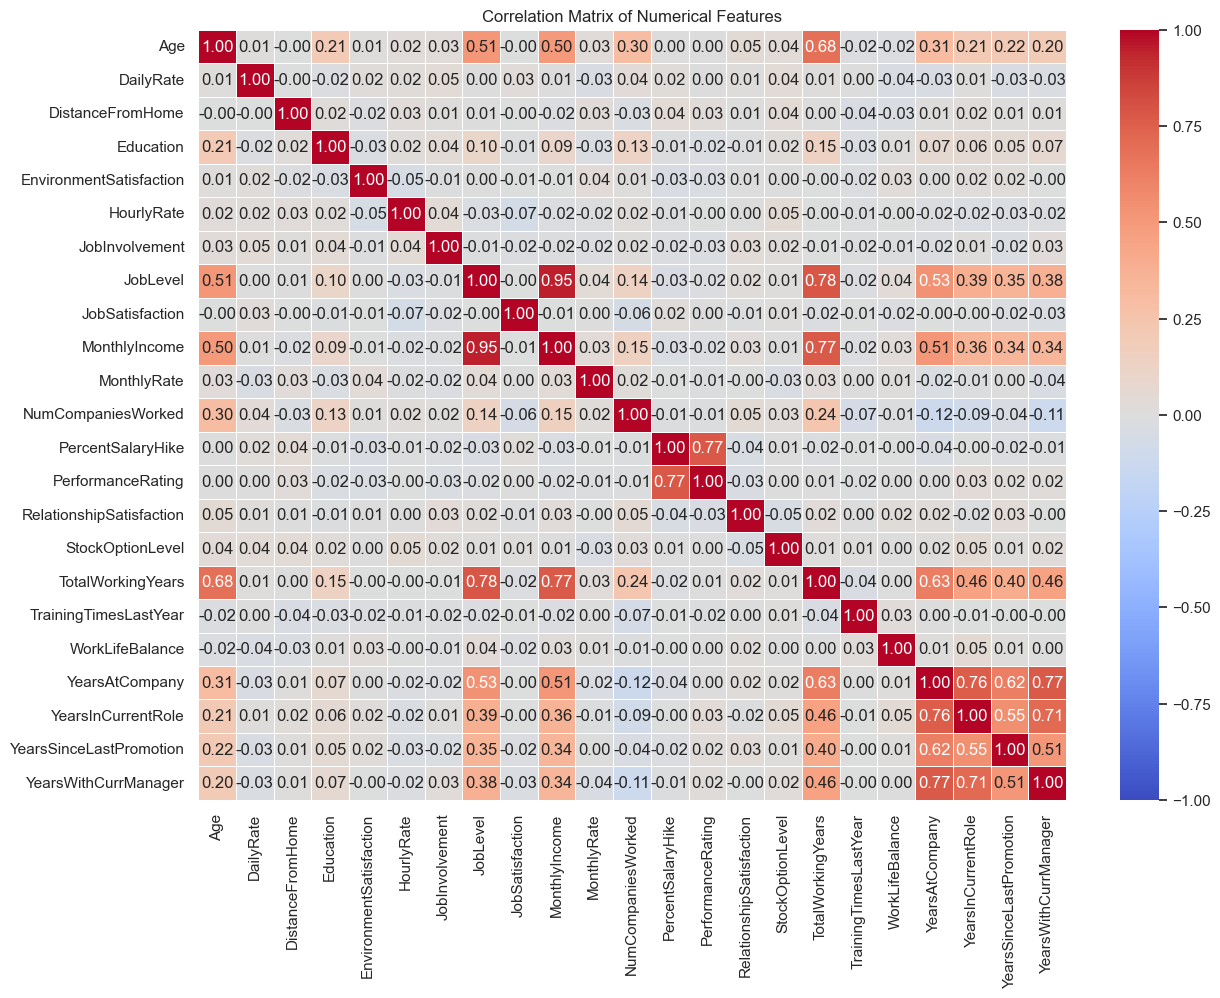

In [20]:
plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    vmin=-1, 
    vmax=1
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

The correlation matrix shows that most numerical features have weak to moderate correlations. The strongest positive correlation is between JobLevel and MonthlyIncome (0.95), indicating that employees with higher job levels generally receive higher salaries. TotalWorkingYears is also strongly correlated with JobLevel (0.78) and MonthlyIncome (0.77). In addition, YearsAtCompany has strong positive relationships with both YearsWithCurrManager (0.77) and YearsInCurrentRole (0.76). Overall, while a few variables are highly correlated, most features provide distinct information, which is useful for clustering analysis.

In [21]:
corr_pairs = corr.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1]

corr_pairs.head(10)

MonthlyIncome         JobLevel                0.950300
JobLevel              MonthlyIncome           0.950300
                      TotalWorkingYears       0.782208
TotalWorkingYears     JobLevel                0.782208
PercentSalaryHike     PerformanceRating       0.773550
PerformanceRating     PercentSalaryHike       0.773550
TotalWorkingYears     MonthlyIncome           0.772893
MonthlyIncome         TotalWorkingYears       0.772893
YearsWithCurrManager  YearsAtCompany          0.769212
YearsAtCompany        YearsWithCurrManager    0.769212
dtype: float64

In [22]:
corr_pairs.tail(10)

NumCompaniesWorked     TrainingTimesLastYear   -0.066054
TrainingTimesLastYear  NumCompaniesWorked      -0.066054
JobSatisfaction        HourlyRate              -0.071335
HourlyRate             JobSatisfaction         -0.071335
YearsInCurrentRole     NumCompaniesWorked      -0.090754
NumCompaniesWorked     YearsInCurrentRole      -0.090754
YearsWithCurrManager   NumCompaniesWorked      -0.110319
NumCompaniesWorked     YearsWithCurrManager    -0.110319
                       YearsAtCompany          -0.118421
YearsAtCompany         NumCompaniesWorked      -0.118421
dtype: float64

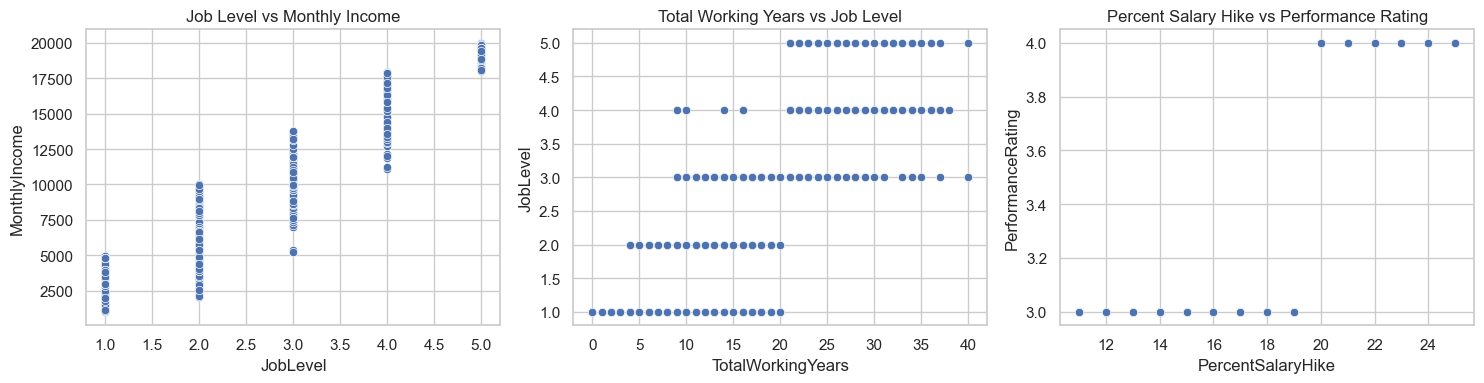

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.scatterplot(
    data=df,
    x='JobLevel',
    y='MonthlyIncome',
    ax=axes[0]
)
axes[0].set_title('Job Level vs Monthly Income')

sns.scatterplot(
    data=df,
    x='TotalWorkingYears',
    y='JobLevel',
    ax=axes[1]
)
axes[1].set_title('Total Working Years vs Job Level')

sns.scatterplot(
    data=df,
    x='PercentSalaryHike',
    y='PerformanceRating',
    ax=axes[2]
)
axes[2].set_title('Percent Salary Hike vs Performance Rating')

plt.tight_layout()
plt.show()

C:\Users\computer\AppData\Local\Temp\ipykernel_17540\2105730203.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


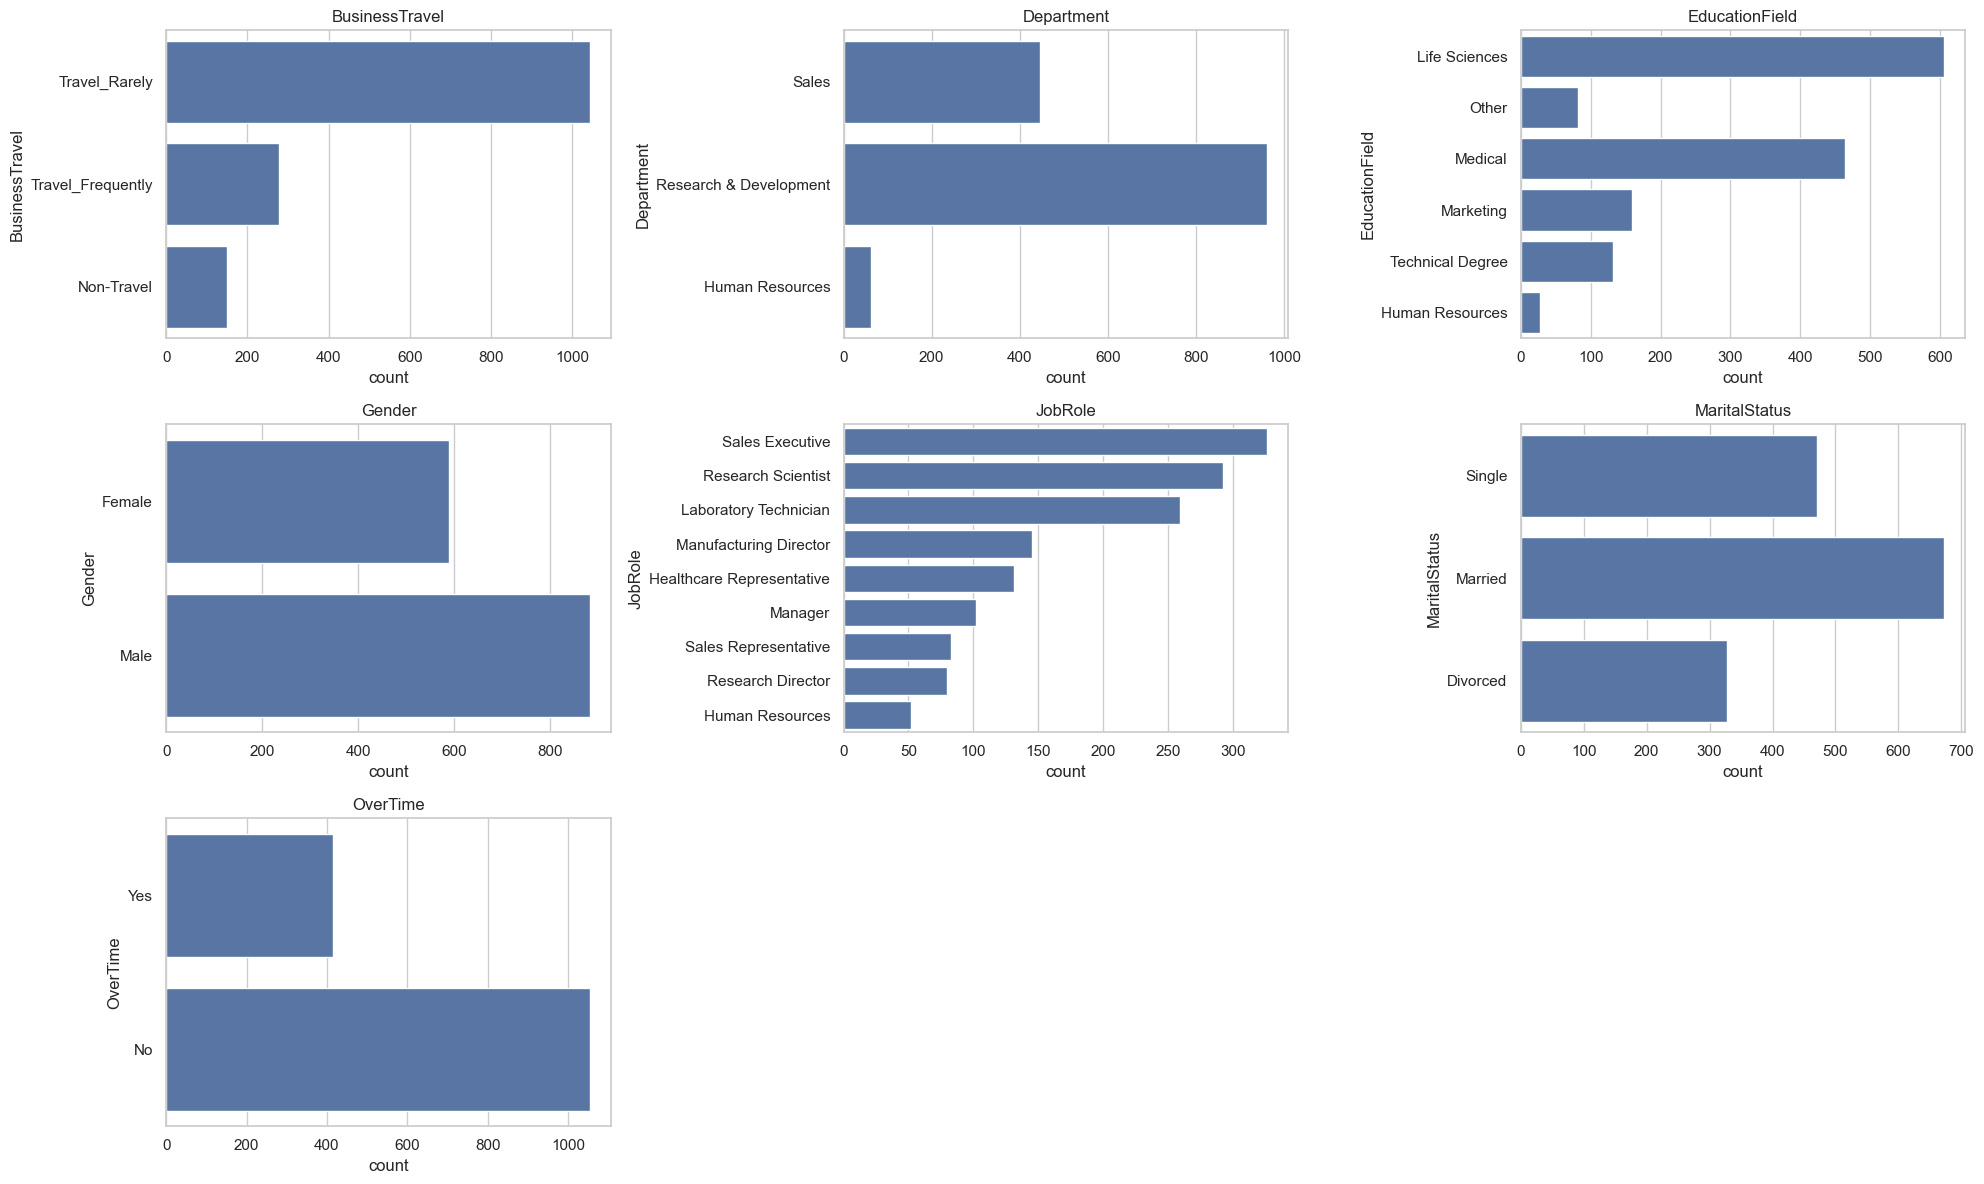

In [24]:
cat_cols = df.select_dtypes(include='object').columns

n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    sns.countplot(data=df, y=col, ax=ax)
    ax.set_title(col)

for ax in axes[len(cat_cols):]:
    ax.remove()

plt.tight_layout()
plt.show()

Count plots were used to visualize the distribution of the categorical variables. The results show that most employees belong to the Research & Development department, while Human Resources has the fewest employees. Most employees travel rarely for business and do not work overtime. In addition, Sales Executive is the most common job role, and Life Sciences is the most common education field. These visualizations provide a better understanding of the distribution of categorical features before applying clustering techniques.

In [25]:
df_encoded = pd.get_dummies(df,drop_first=True)

In [26]:
df.shape

(1470, 30)

In [27]:
df_encoded.shape

(1470, 44)

In [28]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

# model

k=2: 0.116
k=3: 0.097
k=4: 0.105
k=5: 0.094
k=6: 0.106
k=7: 0.101
k=8: 0.101
k=9: 0.101
k=10: 0.088
k=11: 0.095
k=12: 0.099
k=13: 0.091
k=14: 0.086
k=15: 0.085
k=16: 0.084
k=17: 0.081
k=18: 0.076
k=19: 0.080
k=20: 0.074
k=21: 0.076
k=22: 0.073
k=23: 0.071
k=24: 0.073
k=25: 0.059
k=26: 0.071
k=27: 0.071
k=28: 0.063
k=29: 0.065
k=30: 0.065


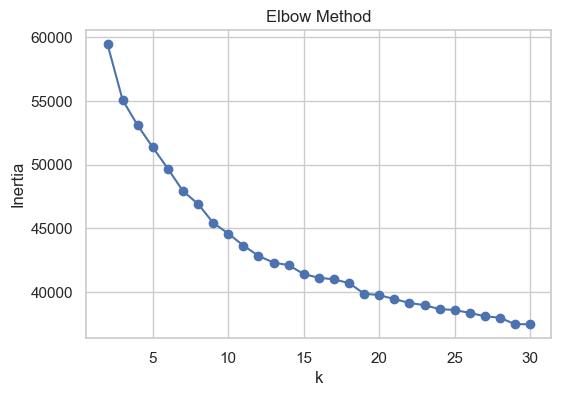

In [29]:
inertia = []
scores = []

for k in range(2, 31):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    inertia.append(kmeans.inertia_)
    
    score = silhouette_score(X_scaled, labels)
    scores.append(score)

    print(f"k={k}: {score:.3f}")

plt.figure(figsize=(6,4))

plt.plot(range(2,31), inertia, marker='o')

plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

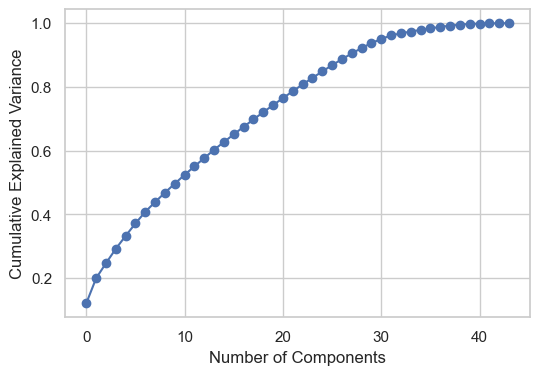

In [30]:
pca = PCA()
pca.fit(X_scaled)

explained = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(6,4))
plt.plot(explained, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

In [31]:
explained[:10]

array([0.12130945, 0.19979097, 0.24685069, 0.29204157, 0.3326264 ,
       0.37169904, 0.40822732, 0.43879025, 0.46834875, 0.49652363])

(1470, 28)
k=2: 0.118
k=3: 0.107
k=4: 0.114
k=5: 0.097
k=6: 0.105
k=7: 0.116
k=8: 0.127
k=9: 0.121
k=10: 0.107
k=11: 0.118
k=12: 0.099
k=13: 0.101
k=14: 0.099
k=15: 0.085
k=16: 0.090
k=17: 0.084
k=18: 0.091
k=19: 0.090
k=20: 0.077
k=21: 0.082
k=22: 0.073
k=23: 0.077
k=24: 0.077
k=25: 0.077
k=26: 0.079
k=27: 0.069
k=28: 0.071
k=29: 0.070
k=30: 0.077


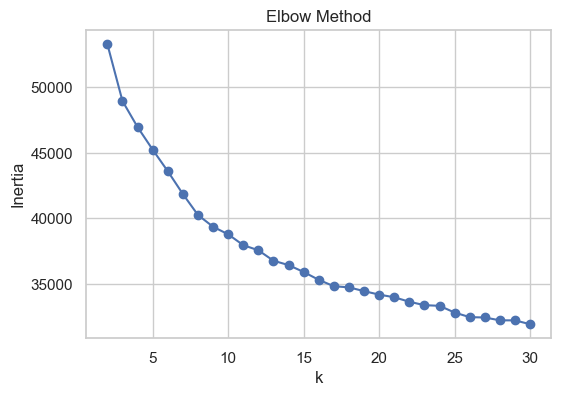

In [32]:
pca = PCA(n_components=0.90)

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

inertia = []
scores = []

for k in range(2, 31):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_pca)

    inertia.append(kmeans.inertia_)

    score = silhouette_score(X_pca, labels)
    scores.append(score)

    print(f"k={k}: {score:.3f}")

plt.figure(figsize=(6,4))

plt.plot(range(2,31), inertia, marker='o')

plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

(1470, 31)
k=2: 0.116
k=3: 0.104
k=4: 0.110
k=5: 0.124
k=6: 0.112
k=7: 0.108
k=8: 0.110
k=9: 0.107
k=10: 0.105
k=11: 0.102
k=12: 0.099
k=13: 0.098
k=14: 0.085
k=15: 0.092
k=16: 0.087
k=17: 0.084
k=18: 0.082
k=19: 0.082
k=20: 0.078
k=21: 0.081
k=22: 0.082
k=23: 0.078
k=24: 0.075
k=25: 0.070
k=26: 0.073
k=27: 0.071
k=28: 0.072
k=29: 0.067
k=30: 0.074


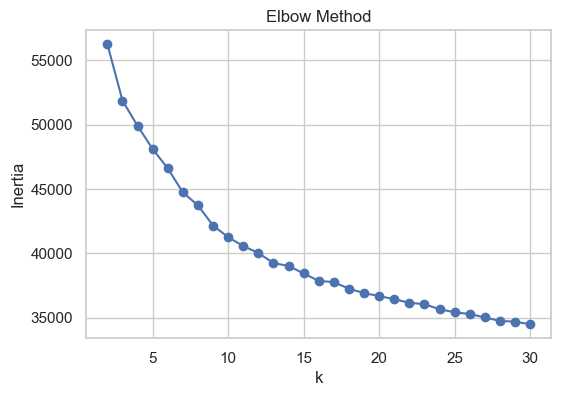

In [33]:
pca2 = PCA(n_components=0.95)

X_pca2 = pca2.fit_transform(X_scaled)

print(X_pca2.shape)

inertia = []
scores = []

for k in range(2, 31):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_pca2)

    inertia.append(kmeans.inertia_)

    score = silhouette_score(X_pca2, labels)
    scores.append(score)

    print(f"k={k}: {score:.3f}")

plt.figure(figsize=(6,4))

plt.plot(range(2,31), inertia, marker='o')

plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [34]:
kmeans = KMeans(
    n_clusters=8,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_pca)

pd.Series(clusters).value_counts().sort_index()

0    116
1    322
2     83
3    344
4    216
5     52
6     80
7    257
Name: count, dtype: int64

# K-Means

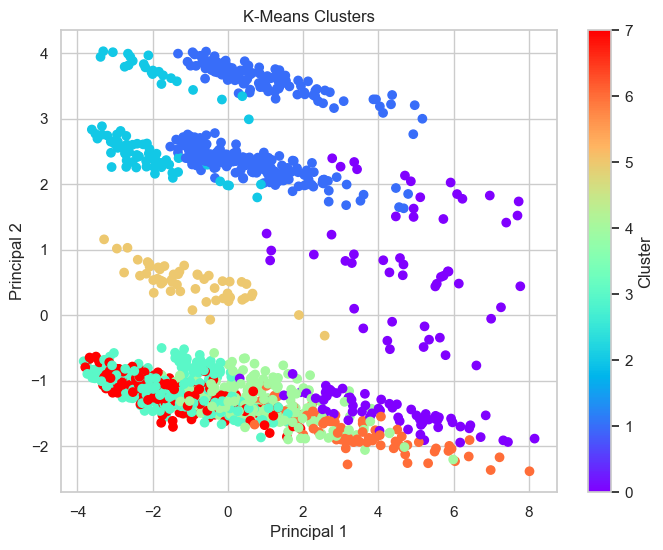

In [35]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0],X_pca[:, 1], c=clusters, cmap="rainbow")

plt.title("K-Means Clusters")
plt.xlabel("Principal 1")
plt.ylabel("Principal 2")
plt.colorbar(label="Cluster")

plt.show()

In [36]:
score = silhouette_score(X_pca, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.12712176082614843


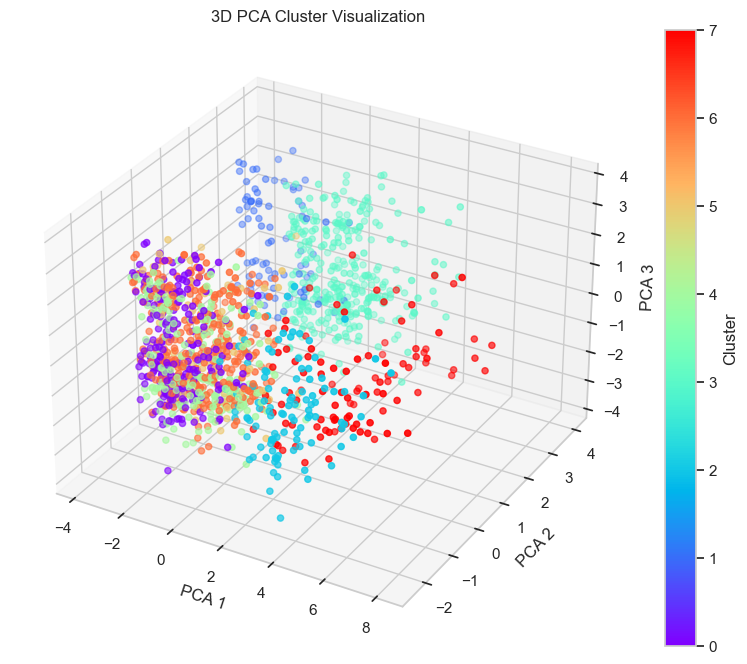

In [37]:
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

kmeans = KMeans(n_clusters=8, random_state=42)
clusters = kmeans.fit_predict(X_pca)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca_3d[:, 0], 
    X_pca_3d[:, 1], 
    X_pca_3d[:, 2], 
    c=clusters, 
    cmap='rainbow', 
    s=20, 
)

ax.set_title("3D PCA Cluster Visualization")
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")

plt.colorbar(scatter, label="Cluster")
plt.show()

# Hierarchical Clustering

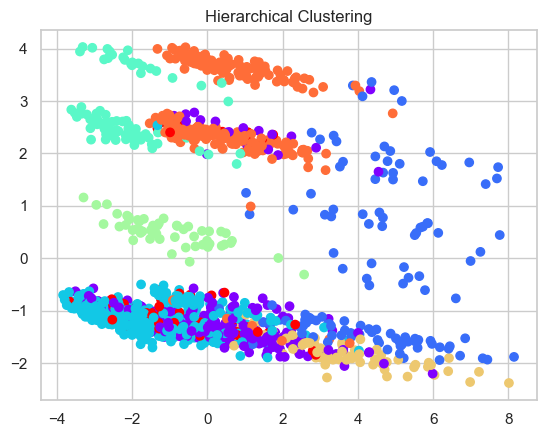

In [38]:
hc = AgglomerativeClustering(n_clusters=8)
clusters_hc = hc.fit_predict(X_pca)

plt.scatter(X_pca[:, 0],X_pca[:, 1], c=clusters_hc, cmap="rainbow")
plt.title("Hierarchical Clustering")
plt.show()

In [39]:
score = silhouette_score(X_pca, clusters_hc)

print("Silhouette Score:", score)

Silhouette Score: 0.11852704368132391


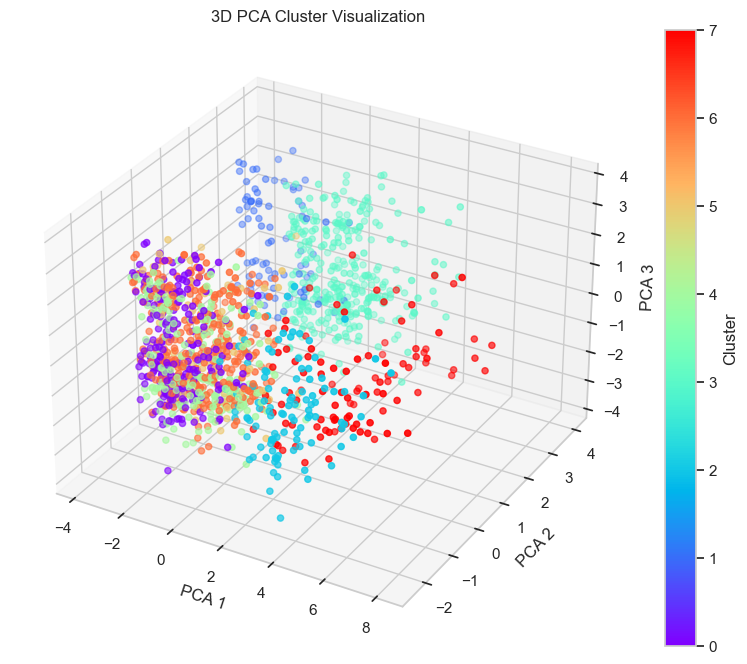

In [40]:
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

hc = AgglomerativeClustering(n_clusters=8)
clusters_hc = hc.fit_predict(X_pca)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca_3d[:, 0], 
    X_pca_3d[:, 1], 
    X_pca_3d[:, 2], 
    c=clusters, 
    cmap='rainbow', 
    s=20, 
)

ax.set_title("3D PCA Cluster Visualization")
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")

plt.colorbar(scatter, label="Cluster")
plt.show()

# DBSCAN

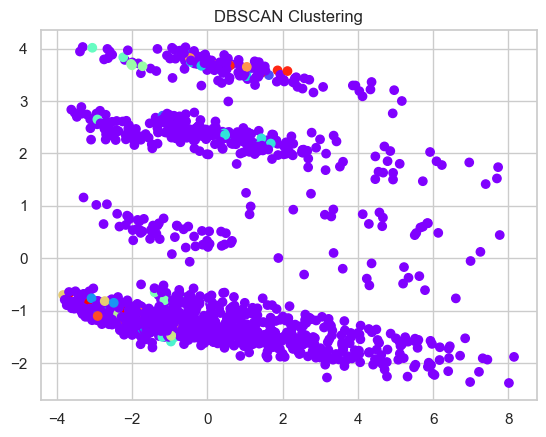

In [41]:
db = DBSCAN(eps=3.5, min_samples=3)
clusters_db = db.fit_predict(X_pca)

plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters_db, cmap="rainbow")
plt.title("DBSCAN Clustering")
plt.show()

In [42]:
print(np.unique(clusters_db, return_counts=True))

(array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16, 17, 18, 19]), array([1391,    4,    5,    3,    4,    3,    5,    6,    3,    3,    5,
          3,    4,    3,    7,    3,    5,    3,    3,    4,    3]))


In [43]:
score = silhouette_score(X_pca, clusters_db)

print("Silhouette Score:", score)

Silhouette Score: -0.2554557993880989


In [44]:
mask = clusters_db != -1

db_score = silhouette_score(X_scaled[mask], clusters_db[mask])

print("DBSCAN Silhouette Score:", db_score)

DBSCAN Silhouette Score: 0.22264573633561427


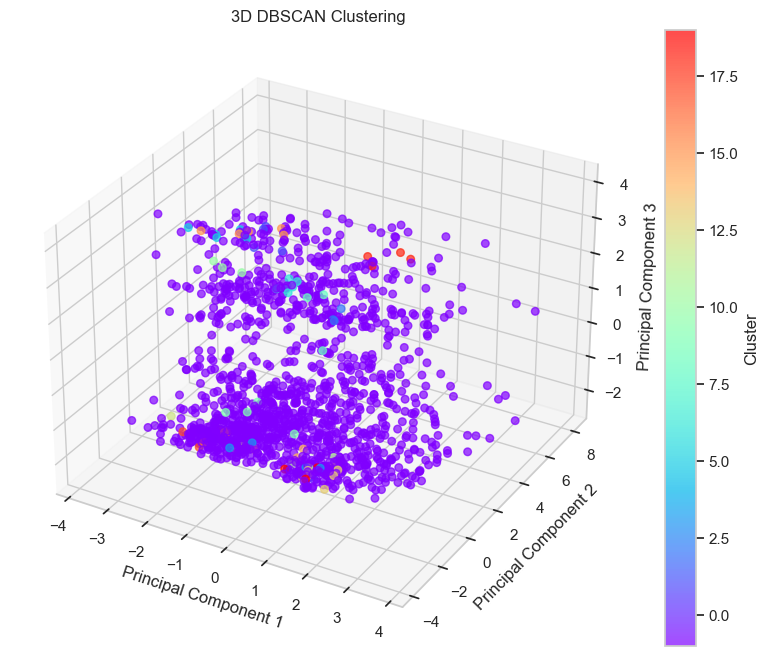

In [45]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    X_pca_3d[:,2],
    X_pca_3d[:,0],
    X_pca_3d[:,1],
    c=clusters_db,
    cmap="rainbow",
    s=30,
    alpha= 0.7
)

ax.set_title("3D DBSCAN Clustering")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")

fig.colorbar(scatter, label="Cluster")

plt.show()

In [46]:
cluster_summary = df.copy()
cluster_summary["Cluster"] = clusters
cluster_summary.groupby("Cluster").mean(numeric_only=True)

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Cluster,,,,,,,,,,,,,,,,,,,,,,,
0,34.117647,793.710084,9.399160,2.802521,2.718487,66.743697,2.684874,1.226891,2.684874,3197.878151,13945.361345,2.550420,15.151261,3.176471,2.722689,0.819328,7.588235,2.962185,2.731092,4.873950,3.142857,1.319328,3.256303
1,30.361446,811.349398,8.662651,2.530120,2.734940,64.337349,2.650602,1.084337,2.734940,2626.000000,14278.204819,1.626506,15.674699,3.144578,2.602410,0.626506,4.674699,3.012048,2.891566,2.915663,2.012048,1.060241,1.662651
2,44.757009,813.719626,8.794393,3.130841,2.504673,64.654206,2.691589,3.850467,2.747664,14818.570093,15278.616822,3.570093,15.261682,3.140187,2.710280,0.841121,22.485981,2.738318,2.822430,12.747664,7.009346,4.121495,6.757009
3,36.858025,801.407407,9.663580,3.012346,2.663580,65.611111,2.716049,2.324074,2.759259,6907.768519,14475.645062,2.719136,14.888889,3.126543,2.700617,0.824074,11.033951,2.839506,2.808642,7.416667,4.845679,2.493827,4.675926
4,36.242718,846.077670,9.868932,2.849515,2.733010,67.553398,2.796117,1.713592,2.650485,4970.446602,14042.631068,2.669903,15.441748,3.150485,2.752427,0.805825,9.669903,2.810680,2.660194,5.694175,3.563107,1.626214,3.451456
5,35.922222,837.488889,9.077778,2.922222,2.966667,66.344444,2.711111,1.633333,2.655556,4672.444444,13793.766667,2.800000,14.911111,3.144444,2.733333,0.744444,9.555556,2.655556,2.755556,5.988889,3.888889,1.977778,3.911111
6,35.531447,775.619497,8.757862,2.924528,2.751572,64.940252,2.761006,1.698113,2.801887,4820.981132,14152.207547,2.635220,15.446541,3.166667,2.669811,0.792453,9.270440,2.641509,2.751572,5.798742,3.814465,1.660377,3.751572
7,47.201923,772.807692,8.173077,3.019231,2.798077,66.548077,2.769231,4.298077,2.701923,17106.230769,15159.913462,3.019231,14.990385,3.182692,2.846154,0.750000,25.057692,2.778846,2.750000,15.163462,6.586538,5.038462,6.288462


## Cluster Interpretation

- Cluster 0:
Employees in this cluster are in the early to mid-stage of their careers. They have an average age of **34 years**, a relatively **low monthly income (≈3,198)**, a **low job level**, and around **8 years of work experience**. This suggests that they are mainly junior employees.

- Cluster 1:
This cluster contains the **youngest employees** (average age **30 years**). They have the **lowest monthly income (≈2,626)**, the **least work experience**, and the **shortest tenure** at the company. This group most likely represents newly hired or early-career employees.

- Cluster 2:
Employees in this cluster are the **most experienced**. They have an average age of **45 years**, a **high monthly income (≈14,819)**, a **high job level**, and more than **22 years of work experience**. These characteristics suggest senior or managerial positions.

- Cluster 3:
This cluster represents employees in the **middle stage of their careers**. They have approximately **11 years of experience**, a **moderate-to-high monthly income (≈6,908)**, and a **medium job level**. They appear to be experienced employees with career progression.

- Cluster 4:
Employees in this cluster have **moderate work experience (≈10 years)** and **moderate salaries (≈4,970)**. Their job level is relatively lower than Cluster 3, indicating mid-level positions.

- Cluster 5:
This cluster is similar to Cluster 4 in terms of age and experience. However, it has the **highest average Environment Satisfaction**, suggesting that these employees are generally more satisfied with their workplace.

- Cluster 6:
Employees in this cluster have **moderate experience (≈9 years)** and **moderate income (≈4,821)**. They also show one of the **highest Job Satisfaction** scores, indicating a relatively positive work experience.

- Cluster 7:
This cluster represents the **most senior employees**. They have the **highest average age (47 years)**, the **highest monthly income (≈17,106)**, the **highest job level**, and the **longest work experience (≈25 years)**. This group likely consists of senior managers or executive-level employees.

## Conclusion

The clustering analysis grouped employees according to their **career stage, work experience, salary, and job level**. The results clearly distinguish between **early-career employees, mid-career employees, and highly experienced senior employees**. These insights can help HR departments improve workforce planning, career development, and employee retention strategies.

# Critical Thinking

## 1. Which algorithm performed best? Why?

K-Means performed the best in this project because it achieved the highest Silhouette Score (approximately **0.127**), indicating better cluster separation and cohesion than Hierarchical Clustering. It also produced balanced and meaningful employee groups. Although DBSCAN achieved a higher score after excluding noise points, this result is not directly comparable because it was calculated on only a subset of the data.

---

## 2. When would you use each algorithm?

### K-Means
Use K-Means when the number of clusters is known in advance and the data forms compact, well-separated groups. It is fast and efficient for large datasets.

### Hierarchical Clustering
Use Hierarchical Clustering when the number of clusters is unknown or when you want to visualize the relationships between clusters using a dendrogram.

### DBSCAN
Use DBSCAN when the dataset contains noise or clusters with irregular shapes. It is useful when the number of clusters is unknown, but it requires careful parameter tuning.

---

## 3. What are the strengths and weaknesses of each algorithm?

| Algorithm | Strengths | Weaknesses |
|-----------|-----------|------------|
| **K-Means** | Fast, simple, and efficient for large datasets | Requires specifying the number of clusters and is sensitive to outliers |
| **Hierarchical Clustering** | Does not require specifying the number of clusters initially and provides a dendrogram | Computationally expensive for large datasets |
| **DBSCAN** | Detects noise and discovers arbitrarily shaped clusters | Sensitive to parameter selection and may perform poorly when cluster densities vary |

---

## Final Insight

Overall, **K-Means** provided the best clustering performance for this employee dataset based on the highest Silhouette Score and the quality of the generated clusters. Hierarchical Clustering produced similar but slightly lower performance. DBSCAN was less suitable because it was highly sensitive to parameter selection and identified many noise points.

# Final Summary (Key Insights)

- The employee data was successfully preprocessed using encoding, feature scaling, and PCA to prepare it for clustering.
- Three clustering algorithms were applied: K-Means, Hierarchical Clustering, and DBSCAN.
- K-Means achieved the best overall performance, with the highest Silhouette Score (≈0.127), producing well-balanced and meaningful employee clusters.
- Hierarchical Clustering produced similar results but with a slightly lower Silhouette Score (≈0.119).
- DBSCAN was less suitable for this dataset because it was highly sensitive to parameter selection and classified many observations as noise.
- The clustering analysis revealed distinct employee groups based on characteristics such as age, work experience, monthly income, and job level.
- These findings can help HR departments better understand employee segments and support decision-making in workforce planning, career development, and employee retention.